<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [42]:
#IMPORTS

import os
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [22]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")


In [23]:
# Step 2 —  Basic dataset checks
print(f"Dataset shape: {df.shape}")
print(f"Duplicate content_ids: {df['content_id'].duplicated().sum()}")
print(f"Overall decline rate: {df['trend_direction'].eq('down').mean():.3f}")
print("duplicate content_id rows:", df["content_id"].duplicated().sum())

Dataset shape: (30000, 44)
Duplicate content_ids: 0
Overall decline rate: 0.542
duplicate content_id rows: 0


In [35]:
# --- Recreate label + rule flags (same logic as w04/w05, unchanged) ---
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)
df["low_ctr_flag"] = (df["avg_position"] <= 20) & (df["ctr"] < CTR_THRESHOLD) & (df["impressions_90d"] >= 500)
df["is_decoy"] = (df["freshness_tier"] == "181+") & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)

# --- Recreate the honest feature set from w06 ---
tier_order = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier_enc"] = df["freshness_tier"].map({t: i for i, t in enumerate(tier_order)})
df["avg_position_missing"] = (df["avg_position"] == 0).astype(int)

FEATURES = ["freshness_tier_enc", "avg_position", "ctr", "impressions_90d", "avg_position_missing"]

## --- Fit RF on the FULL dataset for queue generation ---
# Note: this is different from w06's CV loop on purpose. w06 held out folds to
# measure honest performance (0.872 ± 0.069). This fit uses all rows because
# we're generating an operational queue, not a validation number — the 0.872
# figure from w06 is what we cite as the expected precision, not re-measured here.
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(df[FEATURES], df["is_declining_label"])

# In-sample RF score used only to rank the working queue.
# The validated performance figure comes from grouped CV in w06.
df["model_score"] = rf.predict_proba(df[FEATURES])[:, 1]

# --- Rank and cut the working queue ---
TOP_N = 200  # bigger than the P@50 metric window — this is a real backlog, not just the top 50
queue_df = df.sort_values(["model_score", "impressions_90d"], ascending=[False, False]).head(TOP_N).copy()

# --- Reason codes: built from rule flags only, nothing new invented ---
def reason_code(row):
    if row["is_decoy"]:
        return "high_traffic_stale"
    if row["stale_flag"] and row["low_ctr_flag"]:
        return "stale_and_underperforming"
    if row["avg_position_missing"]:
        return "unranked"
    if row["stale_flag"]:
        return "stale"
    if row["low_ctr_flag"]:
        return "low_ctr"
    return "model_signal_only"  # least explainable — flag for extra review in Section 3

queue_df["reason_code"] = queue_df.apply(reason_code, axis=1)
print(queue_df["reason_code"].value_counts())

reason_code
stale                        148
stale_and_underperforming     49
model_signal_only              3
Name: count, dtype: int64


In [25]:
reason_counts = queue_df["reason_code"].value_counts()

print("\nReason code distribution:")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")


Reason code distribution:
stale: 148
stale_and_underperforming: 49
model_signal_only: 3


In [26]:
main_reason = reason_counts.index[0]
main_count = reason_counts.iloc[0]
main_pct = main_count / len(queue_df) * 100

print(
    f"\nMost common reason code: {main_reason} "
    f"({main_count} pages, {main_pct:.1f}% of the queue)"
)


Most common reason code: stale (148 pages, 74.0% of the queue)


#### Decay and refresh insight

The reason-code distribution shows which conditions are most common in the working queue. The largest group is `stale`, which indicates that content age is an important reason pages are being prioritized. The other reason codes separate pages that need different types of review.

This supports a tiered workflow rather than treating the queue as one list requiring the same action:

- **Proactive maintenance (`stale`):** Schedule routine content refreshes for aging pages.
- **Targeted fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta review when weak CTR is part of the reason.
- **Technical checks (`unranked`):** Investigate indexing or ranking-data issues before assigning content work.
- **Priority review (`high_traffic_stale`):** Review older pages with meaningful traffic earlier because more existing traffic may be at risk.
- **Manual audits (`model_signal_only`):** Review cases where the model flags risk without a rule-based explanation.

In [39]:
# --- Archetype -> action mapping ---
# EDIT THIS DICT YOURSELF — the mapping is your judgment call, not the model's.
# Format: archetype -> recommended action
ARCHETYPE_ACTIONS = {
    "stale_and_underperforming": "Rewrite title + meta description (cheap, fast)",
    "high_traffic_stale": "Priority full refresh — traffic at risk",
    "unranked": "Check indexing/technical issues before content work",
    "stale": "Schedule for content refresh",
    "low_ctr": "Review title/meta for click appeal",
    "model_signal_only": "Manual review — no clear rule reason, verify before acting",
}
queue_df["recommended_action"] = queue_df["reason_code"].map(ARCHETYPE_ACTIONS)

### Reason codes & queue analysis

Reason codes are assigned using rule-based checks rather than raw model outputs to keep recommendations transparent and actionable.

#### Reason codes
* **`high_traffic_stale`** – Oldest freshness tier with $\ge$5,000 impressions (last 90 days); high priority due to high exposure risk.
* **`stale_and_underperforming`** – Outdated page with low CTR despite ranking in the top 20; strong candidate for title/meta or content tweaks.
* **`unranked`** – Average position is 0 (missing ranking data); requires technical or indexing verification before editing content.
* **`stale`** – Old enough to consider a refresh, but doesn't trigger higher-severity traffic or CTR flags.
* **`low_ctr`** – Low CTR despite a solid average position and impression volume; prioritize title and meta tag updates.
* **`model_signal_only`** – Predicted for decline without triggering rule flags; requires manual editor review.



#### Archetype → action mapping

Actions serve as low-effort starting points for editorial review rather than automated fixes:

* **`high_traffic_stale` → Priority full refresh:** Old pages with significant traffic ($\ge$5,000 impressions) have meaningful existing traffic and therefore deserve earlier review.
* **`stale_and_underperforming` → Rewrite title & meta description:** A cheap, fast first step to recover weak CTR on aging pages before committing to a full rewrite.
* **`unranked` → Check technical indexing:** Investigate Search Console and index status before wasting editorial time updating copy.
* **`stale` → Schedule for routine refresh:** Add to the standard content maintenance backlog; age is the only trigger, so no urgent intervention is required.
* **`low_ctr` → Optimize metadata:** Strong average positions with poor CTR indicate a snippet/title problem, making metadata tweaks a reasonable low-cost first step.
* **`model_signal_only` → Manual review:** Requires human judgment to identify silent decline factors since no explicit rule flags were triggered.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [28]:
print(f"Dataset: {df.shape[0]} rows, {df['client_id'].nunique()} clients, single snapshot")
print(f"Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069")
print(f"Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124")

Dataset: 30000 rows, 32 clients, single snapshot
Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069
Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124


### Intended use and limitations

This model is a **decision-support tool, not an automated decision-maker**. .

#### Key limitations and validation risks

- **No time-based validation:** The model was built using a single cross-sectional snapshot of data. It has not been evaluated with a forward-looking time split, so its performance on future content changes is still unknown.
-  **Client imbalance and fold variability:** The dataset contains 30,000 pages from 32 clients, and the number of pages is not evenly distributed across clients. Grouped cross-validation produced a Precision@50 of **0.872 ± 0.069** for the Random Forest, showing that performance varies between client groups. Other model versions showed even larger fold-to-fold variability.
- **No out-of-sample client testing:** The model has only been evaluated on clients included in this dataset. It has not been validated on new or unseen clients, so its ability to generalize beyond this data remains unknown.

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
#IMPORTS

import os
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")


In [ ]:
# Step 2 —  Basic dataset checks
print(f"Dataset shape: {df.shape}")
print(f"Duplicate content_ids: {df['content_id'].duplicated().sum()}")
print(f"Overall decline rate: {df['trend_direction'].eq('down').mean():.3f}")
print("duplicate content_id rows:", df["content_id"].duplicated().sum())

Dataset shape: (30000, 44)
Duplicate content_ids: 0
Overall decline rate: 0.542
duplicate content_id rows: 0


In [ ]:
# --- Recreate label + rule flags (same logic as w04/w05, unchanged) ---
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)
df["low_ctr_flag"] = (df["avg_position"] <= 20) & (df["ctr"] < CTR_THRESHOLD) & (df["impressions_90d"] >= 500)
df["is_decoy"] = (df["freshness_tier"] == "181+") & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)

# --- Recreate the honest feature set from w06 ---
tier_order = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier_enc"] = df["freshness_tier"].map({t: i for i, t in enumerate(tier_order)})
df["avg_position_missing"] = (df["avg_position"] == 0).astype(int)

FEATURES = ["freshness_tier_enc", "avg_position", "ctr", "impressions_90d", "avg_position_missing"]

## --- Fit RF on the FULL dataset for queue generation ---
# Note: this is different from w06's CV loop on purpose. w06 held out folds to
# measure honest performance (0.872 ± 0.069). This fit uses all rows because
# we're generating an operational queue, not a validation number — the 0.872
# figure from w06 is what we cite as the expected precision, not re-measured here.
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(df[FEATURES], df["is_declining_label"])

# In-sample RF score used only to rank the working queue.
# The validated performance figure comes from grouped CV in w06.
df["model_score"] = rf.predict_proba(df[FEATURES])[:, 1]

# --- Rank and cut the working queue ---
TOP_N = 200  # bigger than the P@50 metric window — this is a real backlog, not just the top 50
queue_df = df.sort_values(["model_score", "impressions_90d"], ascending=[False, False]).head(TOP_N).copy()

# --- Reason codes: built from rule flags only, nothing new invented ---
def reason_code(row):
    if row["is_decoy"]:
        return "high_traffic_stale"
    if row["stale_flag"] and row["low_ctr_flag"]:
        return "stale_and_underperforming"
    if row["avg_position_missing"]:
        return "unranked"
    if row["stale_flag"]:
        return "stale"
    if row["low_ctr_flag"]:
        return "low_ctr"
    return "model_signal_only"  # least explainable — flag for extra review in Section 3

queue_df["reason_code"] = queue_df.apply(reason_code, axis=1)
print(queue_df["reason_code"].value_counts())

reason_code
stale                        148
stale_and_underperforming     49
model_signal_only              3
Name: count, dtype: int64


In [ ]:
reason_counts = queue_df["reason_code"].value_counts()

print("\nReason code distribution:")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")


Reason code distribution:
stale: 148
stale_and_underperforming: 49
model_signal_only: 3


In [ ]:
main_reason = reason_counts.index[0]
main_count = reason_counts.iloc[0]
main_pct = main_count / len(queue_df) * 100

print(
    f"\nMost common reason code: {main_reason} "
    f"({main_count} pages, {main_pct:.1f}% of the queue)"
)


Most common reason code: stale (148 pages, 74.0% of the queue)


#### Decay and refresh insight

The reason-code distribution shows which conditions are most common in the working queue. The largest group is `stale`, which indicates that content age is an important reason pages are being prioritized. The other reason codes separate pages that need different types of review.

This supports a tiered workflow rather than treating the queue as one list requiring the same action:

- **Proactive maintenance (`stale`):** Schedule routine content refreshes for aging pages.
- **Targeted fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta review when weak CTR is part of the reason.
- **Technical checks (`unranked`):** Investigate indexing or ranking-data issues before assigning content work.
- **Priority review (`high_traffic_stale`):** Review older pages with meaningful traffic earlier because more existing traffic may be at risk.
- **Manual audits (`model_signal_only`):** Review cases where the model flags risk without a rule-based explanation.

In [ ]:
# --- Archetype -> action mapping ---
# EDIT THIS DICT YOURSELF — the mapping is your judgment call, not the model's.
# Format: archetype -> recommended action
ARCHETYPE_ACTIONS = {
    "stale_and_underperforming": "Rewrite title + meta description (cheap, fast)",
    "high_traffic_stale": "Priority full refresh — traffic at risk",
    "unranked": "Check indexing/technical issues before content work",
    "stale": "Schedule for content refresh",
    "low_ctr": "Review title/meta for click appeal",
    "model_signal_only": "Manual review — no clear rule reason, verify before acting",
}
queue_df["recommended_action"] = queue_df["reason_code"].map(ARCHETYPE_ACTIONS)

### Reason codes & queue analysis

Reason codes are assigned using rule-based checks rather than raw model outputs to keep recommendations transparent and actionable.

#### Reason codes
* **`high_traffic_stale`** – Oldest freshness tier with $\ge$5,000 impressions (last 90 days); high priority due to high exposure risk.
* **`stale_and_underperforming`** – Outdated page with low CTR despite ranking in the top 20; strong candidate for title/meta or content tweaks.
* **`unranked`** – Average position is 0 (missing ranking data); requires technical or indexing verification before editing content.
* **`stale`** – Old enough to consider a refresh, but doesn't trigger higher-severity traffic or CTR flags.
* **`low_ctr`** – Low CTR despite a solid average position and impression volume; prioritize title and meta tag updates.
* **`model_signal_only`** – Predicted for decline without triggering rule flags; requires manual editor review.



#### Archetype → action mapping

Actions serve as low-effort starting points for editorial review rather than automated fixes:

* **`high_traffic_stale` → Priority full refresh:** Old pages with significant traffic ($\ge$5,000 impressions) have meaningful existing traffic and therefore deserve earlier review.
* **`stale_and_underperforming` → Rewrite title & meta description:** A cheap, fast first step to recover weak CTR on aging pages before committing to a full rewrite.
* **`unranked` → Check technical indexing:** Investigate Search Console and index status before wasting editorial time updating copy.
* **`stale` → Schedule for routine refresh:** Add to the standard content maintenance backlog; age is the only trigger, so no urgent intervention is required.
* **`low_ctr` → Optimize metadata:** Strong average positions with poor CTR indicate a snippet/title problem, making metadata tweaks a reasonable low-cost first step.
* **`model_signal_only` → Manual review:** Requires human judgment to identify silent decline factors since no explicit rule flags were triggered.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
print(f"Dataset: {df.shape[0]} rows, {df['client_id'].nunique()} clients, single snapshot")
print(f"Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069")
print(f"Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124")

Dataset: 30000 rows, 32 clients, single snapshot
Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069
Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124


### Intended use and limitations

This model is a **decision-support tool, not an automated decision-maker**.

#### Key limitations and validation risks

- **No time-based validation:** The model was built using a single cross-sectional snapshot of data. It has not been evaluated with a forward-looking time split, so its performance on future content changes is still unknown.
-  **Client imbalance and fold variability:** The dataset contains 30,000 pages from 32 clients, and the number of pages is not evenly distributed across clients. Grouped cross-validation produced a Precision@50 of **0.872 ± 0.069** for the Random Forest, showing that performance varies between client groups. Other model versions showed even larger fold-to-fold variability.
- **No out-of-sample client testing:** The model has only been evaluated on clients included in this dataset. It has not been validated on new or unseen clients, so its ability to generalize beyond this data remains unknown.

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
#IMPORTS

import os
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")


In [ ]:
# Step 2 —  Basic dataset checks
print(f"Dataset shape: {df.shape}")
print(f"Duplicate content_ids: {df['content_id'].duplicated().sum()}")
print(f"Overall decline rate: {df['trend_direction'].eq('down').mean():.3f}")
print("duplicate content_id rows:", df["content_id"].duplicated().sum())

Dataset shape: (30000, 44)
Duplicate content_ids: 0
Overall decline rate: 0.542
duplicate content_id rows: 0


In [ ]:
# --- Recreate label + rule flags (same logic as w04/w05, unchanged) ---
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)
df["low_ctr_flag"] = (df["avg_position"] <= 20) & (df["ctr"] < CTR_THRESHOLD) & (df["impressions_90d"] >= 500)
df["is_decoy"] = (df["freshness_tier"] == "181+") & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)

# --- Recreate the honest feature set from w06 ---
tier_order = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier_enc"] = df["freshness_tier"].map({t: i for i, t in enumerate(tier_order)})
df["avg_position_missing"] = (df["avg_position"] == 0).astype(int)

FEATURES = ["freshness_tier_enc", "avg_position", "ctr", "impressions_90d", "avg_position_missing"]

## --- Fit RF on the FULL dataset for queue generation ---
# Note: this is different from w06's CV loop on purpose. w06 held out folds to
# measure honest performance (0.872 ± 0.069). This fit uses all rows because
# we're generating an operational queue, not a validation number — the 0.872
# figure from w06 is what we cite as the expected precision, not re-measured here.
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(df[FEATURES], df["is_declining_label"])

# In-sample RF score used only to rank the working queue.
# The validated performance figure comes from grouped CV in w06.
df["model_score"] = rf.predict_proba(df[FEATURES])[:, 1]

# --- Rank and cut the working queue ---
TOP_N = 200  # bigger than the P@50 metric window — this is a real backlog, not just the top 50
queue_df = df.sort_values(["model_score", "impressions_90d"], ascending=[False, False]).head(TOP_N).copy()

# --- Reason codes: built from rule flags only, nothing new invented ---
def reason_code(row):
    if row["is_decoy"]:
        return "high_traffic_stale"
    if row["stale_flag"] and row["low_ctr_flag"]:
        return "stale_and_underperforming"
    if row["avg_position_missing"]:
        return "unranked"
    if row["stale_flag"]:
        return "stale"
    if row["low_ctr_flag"]:
        return "low_ctr"
    return "model_signal_only"  # least explainable — flag for extra review in Section 3

queue_df["reason_code"] = queue_df.apply(reason_code, axis=1)
print(queue_df["reason_code"].value_counts())

reason_code
stale                        148
stale_and_underperforming     49
model_signal_only              3
Name: count, dtype: int64


In [ ]:
reason_counts = queue_df["reason_code"].value_counts()

print("\nReason code distribution:")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")


Reason code distribution:
stale: 148
stale_and_underperforming: 49
model_signal_only: 3


In [ ]:
main_reason = reason_counts.index[0]
main_count = reason_counts.iloc[0]
main_pct = main_count / len(queue_df) * 100

print(
    f"\nMost common reason code: {main_reason} "
    f"({main_count} pages, {main_pct:.1f}% of the queue)"
)


Most common reason code: stale (148 pages, 74.0% of the queue)


#### Decay and refresh insight

The reason-code distribution shows which conditions are most common in the working queue. The largest group is `stale`, which indicates that content age is an important reason pages are being prioritized. The other reason codes separate pages that need different types of review.

This supports a tiered workflow rather than treating the queue as one list requiring the same action:

- **Proactive maintenance (`stale`):** Schedule routine content refreshes for aging pages.
- **Targeted fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta review when weak CTR is part of the reason.
- **Technical checks (`unranked`):** Investigate indexing or ranking-data issues before assigning content work.
- **Priority review (`high_traffic_stale`):** Review older pages with meaningful traffic earlier because more existing traffic may be at risk.
- **Manual audits (`model_signal_only`):** Review cases where the model flags risk without a rule-based explanation.

In [ ]:
# --- Archetype -> action mapping ---
# EDIT THIS DICT YOURSELF — the mapping is your judgment call, not the model's.
# Format: archetype -> recommended action
ARCHETYPE_ACTIONS = {
    "stale_and_underperforming": "Rewrite title + meta description (cheap, fast)",
    "high_traffic_stale": "Priority full refresh — traffic at risk",
    "unranked": "Check indexing/technical issues before content work",
    "stale": "Schedule for content refresh",
    "low_ctr": "Review title/meta for click appeal",
    "model_signal_only": "Manual review — no clear rule reason, verify before acting",
}
queue_df["recommended_action"] = queue_df["reason_code"].map(ARCHETYPE_ACTIONS)

### Reason codes & queue analysis

Reason codes are assigned using rule-based checks rather than raw model outputs to keep recommendations transparent and actionable.

#### Reason codes
* **`high_traffic_stale`** – Oldest freshness tier with $\ge$5,000 impressions (last 90 days); high priority due to high exposure risk.
* **`stale_and_underperforming`** – Outdated page with low CTR despite ranking in the top 20; strong candidate for title/meta or content tweaks.
* **`unranked`** – Average position is 0 (missing ranking data); requires technical or indexing verification before editing content.
* **`stale`** – Old enough to consider a refresh, but doesn't trigger higher-severity traffic or CTR flags.
* **`low_ctr`** – Low CTR despite a solid average position and impression volume; prioritize title and meta tag updates.
* **`model_signal_only`** – Predicted for decline without triggering rule flags; requires manual editor review.



#### Archetype → action mapping

Actions serve as low-effort starting points for editorial review rather than automated fixes:

* **`high_traffic_stale` → Priority full refresh:** Old pages with significant traffic ($\ge$5,000 impressions) have meaningful existing traffic and therefore deserve earlier review.
* **`stale_and_underperforming` → Rewrite title & meta description:** A cheap, fast first step to recover weak CTR on aging pages before committing to a full rewrite.
* **`unranked` → Check technical indexing:** Investigate Search Console and index status before wasting editorial time updating copy.
* **`stale` → Schedule for routine refresh:** Add to the standard content maintenance backlog; age is the only trigger, so no urgent intervention is required.
* **`low_ctr` → Optimize metadata:** Strong average positions with poor CTR indicate a snippet/title problem, making metadata tweaks a reasonable low-cost first step.
* **`model_signal_only` → Manual review:** Requires human judgment to identify silent decline factors since no explicit rule flags were triggered.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
print(f"Dataset: {df.shape[0]} rows, {df['client_id'].nunique()} clients, single snapshot")
print(f"Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069")
print(f"Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124")

Dataset: 30000 rows, 32 clients, single snapshot
Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069
Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124


### Intended use and limitations

This model is a **decision-support tool, not an automated decision-maker**.

#### Key limitations and validation risks

- **No time-based validation:** The model was built using a single cross-sectional snapshot of data. It has not been evaluated with a forward-looking time split, so its performance on future content changes is still unknown.
-  **Client imbalance and fold variability:** The dataset contains 30,000 pages from 32 clients, and the number of pages is not evenly distributed across clients. Grouped cross-validation produced a Precision@50 of **0.872 ± 0.069** for the Random Forest, showing that performance varies between client groups. Other model versions showed even larger fold-to-fold variability.
- **No out-of-sample client testing:** The model has only been evaluated on clients included in this dataset. It has not been validated on new or unseen clients, so its ability to generalize beyond this data remains unknown.

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
#IMPORTS

import os
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")


In [ ]:
# Step 2 —  Basic dataset checks
print(f"Dataset shape: {df.shape}")
print(f"Duplicate content_ids: {df['content_id'].duplicated().sum()}")
print(f"Overall decline rate: {df['trend_direction'].eq('down').mean():.3f}")
print("duplicate content_id rows:", df["content_id"].duplicated().sum())

Dataset shape: (30000, 44)
Duplicate content_ids: 0
Overall decline rate: 0.542
duplicate content_id rows: 0


In [ ]:
# --- Recreate label + rule flags (same logic as w04/w05, unchanged) ---
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)
df["low_ctr_flag"] = (df["avg_position"] <= 20) & (df["ctr"] < CTR_THRESHOLD) & (df["impressions_90d"] >= 500)
df["is_decoy"] = (df["freshness_tier"] == "181+") & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)

# --- Recreate the honest feature set from w06 ---
tier_order = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier_enc"] = df["freshness_tier"].map({t: i for i, t in enumerate(tier_order)})
df["avg_position_missing"] = (df["avg_position"] == 0).astype(int)

FEATURES = ["freshness_tier_enc", "avg_position", "ctr", "impressions_90d", "avg_position_missing"]

## --- Fit RF on the FULL dataset for queue generation ---
# Note: this is different from w06's CV loop on purpose. w06 held out folds to
# measure honest performance (0.872 ± 0.069). This fit uses all rows because
# we're generating an operational queue, not a validation number — the 0.872
# figure from w06 is what we cite as the expected precision, not re-measured here.
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(df[FEATURES], df["is_declining_label"])

# In-sample RF score used only to rank the working queue.
# The validated performance figure comes from grouped CV in w06.
df["model_score"] = rf.predict_proba(df[FEATURES])[:, 1]

# --- Rank and cut the working queue ---
TOP_N = 200  # bigger than the P@50 metric window — this is a real backlog, not just the top 50
queue_df = df.sort_values(["model_score", "impressions_90d"], ascending=[False, False]).head(TOP_N).copy()

# --- Reason codes: built from rule flags only, nothing new invented ---
def reason_code(row):
    if row["is_decoy"]:
        return "high_traffic_stale"
    if row["stale_flag"] and row["low_ctr_flag"]:
        return "stale_and_underperforming"
    if row["avg_position_missing"]:
        return "unranked"
    if row["stale_flag"]:
        return "stale"
    if row["low_ctr_flag"]:
        return "low_ctr"
    return "model_signal_only"  # least explainable — flag for extra review in Section 3

queue_df["reason_code"] = queue_df.apply(reason_code, axis=1)
print(queue_df["reason_code"].value_counts())

reason_code
stale                        148
stale_and_underperforming     49
model_signal_only              3
Name: count, dtype: int64


In [ ]:
reason_counts = queue_df["reason_code"].value_counts()

print("\nReason code distribution:")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")


Reason code distribution:
stale: 148
stale_and_underperforming: 49
model_signal_only: 3


In [ ]:
main_reason = reason_counts.index[0]
main_count = reason_counts.iloc[0]
main_pct = main_count / len(queue_df) * 100

print(
    f"\nMost common reason code: {main_reason} "
    f"({main_count} pages, {main_pct:.1f}% of the queue)"
)


Most common reason code: stale (148 pages, 74.0% of the queue)


#### Decay and refresh insight

The reason-code distribution shows which conditions are most common in the working queue. The largest group is `stale`, which indicates that content age is an important reason pages are being prioritized. The other reason codes separate pages that need different types of review.

This supports a tiered workflow rather than treating the queue as one list requiring the same action:

- **Proactive maintenance (`stale`):** Schedule routine content refreshes for aging pages.
- **Targeted fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta review when weak CTR is part of the reason.
- **Technical checks (`unranked`):** Investigate indexing or ranking-data issues before assigning content work.
- **Priority review (`high_traffic_stale`):** Review older pages with meaningful traffic earlier because more existing traffic may be at risk.
- **Manual audits (`model_signal_only`):** Review cases where the model flags risk without a rule-based explanation.

In [ ]:
# --- Archetype -> action mapping ---
# EDIT THIS DICT YOURSELF — the mapping is your judgment call, not the model's.
# Format: archetype -> recommended action
ARCHETYPE_ACTIONS = {
    "stale_and_underperforming": "Rewrite title + meta description (cheap, fast)",
    "high_traffic_stale": "Priority full refresh — traffic at risk",
    "unranked": "Check indexing/technical issues before content work",
    "stale": "Schedule for content refresh",
    "low_ctr": "Review title/meta for click appeal",
    "model_signal_only": "Manual review — no clear rule reason, verify before acting",
}
queue_df["recommended_action"] = queue_df["reason_code"].map(ARCHETYPE_ACTIONS)

### Reason codes & queue analysis

Reason codes are assigned using rule-based checks rather than raw model outputs to keep recommendations transparent and actionable.

#### Reason codes
* **`high_traffic_stale`** – Oldest freshness tier with $\ge$5,000 impressions (last 90 days); high priority due to high exposure risk.
* **`stale_and_underperforming`** – Outdated page with low CTR despite ranking in the top 20; strong candidate for title/meta or content tweaks.
* **`unranked`** – Average position is 0 (missing ranking data); requires technical or indexing verification before editing content.
* **`stale`** – Old enough to consider a refresh, but doesn't trigger higher-severity traffic or CTR flags.
* **`low_ctr`** – Low CTR despite a solid average position and impression volume; prioritize title and meta tag updates.
* **`model_signal_only`** – Predicted for decline without triggering rule flags; requires manual editor review.



#### Archetype → action mapping

Actions serve as low-effort starting points for editorial review rather than automated fixes:

* **`high_traffic_stale` → Priority full refresh:** Old pages with significant traffic ($\ge$5,000 impressions) have meaningful existing traffic and therefore deserve earlier review.
* **`stale_and_underperforming` → Rewrite title & meta description:** A cheap, fast first step to recover weak CTR on aging pages before committing to a full rewrite.
* **`unranked` → Check technical indexing:** Investigate Search Console and index status before wasting editorial time updating copy.
* **`stale` → Schedule for routine refresh:** Add to the standard content maintenance backlog; age is the only trigger, so no urgent intervention is required.
* **`low_ctr` → Optimize metadata:** Strong average positions with poor CTR indicate a snippet/title problem, making metadata tweaks a reasonable low-cost first step.
* **`model_signal_only` → Manual review:** Requires human judgment to identify silent decline factors since no explicit rule flags were triggered.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
print(f"Dataset: {df.shape[0]} rows, {df['client_id'].nunique()} clients, single snapshot")
print(f"Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069")
print(f"Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124")

Dataset: 30000 rows, 32 clients, single snapshot
Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069
Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124


### Intended use and limitations

This model is a **decision-support tool, not an automated decision-maker**. It ranks pages using an RF score to help editors prioritize which pages to review first which pages to review first, but all final actions require human judgment.

#### Key limitations and validation risks

- **No time-based validation:** The model was built using a single cross-sectional snapshot of data. It has not been evaluated with a forward-looking time split, so its performance on future content changes is still unknown.
-  **Client imbalance and fold variability:** The dataset contains 30,000 pages from 32 clients, and the number of pages is not evenly distributed across clients. Grouped cross-validation produced a Precision@50 of **0.872 ± 0.069** for the Random Forest, showing that performance varies between client groups. Other model versions showed even larger fold-to-fold variability.
- **No out-of-sample client testing:** The model has only been evaluated on clients included in this dataset. It has not been validated on new or unseen clients, so its ability to generalize beyond this data remains unknown.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# Flag rows needing mandatory review before any action

needs_review = queue_df[
    (queue_df["reason_code"] == "model_signal_only") |
    (queue_df["model_score"] < queue_df["model_score"].quantile(0.6))
].copy()

review_count = len(needs_review)
queue_count = len(queue_df)
review_pct = review_count / queue_count * 100

print(
    f"{review_count} of {queue_count} queue rows "
    f"flagged for mandatory review ({review_pct:.1f}%)"
)

120 of 200 queue rows flagged for mandatory review (60.0%)


### Human review and guardrails


Of the top 200 queue recommendations, **120 pages (60%) require mandatory human review** before taking action.

Review triggers are split into two categories:
* **`model_signal_only` cases:** Pages flagged by the model without clear rule-based triggers.
* **Marginal-confidence scores:** Pages sitting near the lower score threshold of the top-200 queue.

> **Key takeaway:** These guardrails ensure the model operates strictly as a decision-support ranking tool. Automated script execution across these flagged rows is prohibited—final actions require explicit editorial sign-off.


#### Cost/value logic & prioritization strategy

Because editorial review time is finite, the queue prioritizes low-cost, high-impact interventions before escalating to expensive content rewrites.

* **Protect high-exposure traffic (`high_traffic_stale`):** Prioritize these first. Since these pages already drive significant volume ($\ge$5,000 impressions), preventing traffic decay yields the highest relative ROI.
* **Default to low-cost fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta description rewrites. Metadata tweaks take minutes; full page rewrites take hours.
* **Filter out technical false positives (`unranked`):** Audit Search Console for indexing issues before assigning content work. Rewriting copy won't fix a page that Google isn't indexing.
* **Require human triage for edge cases (`model_signal_only`):** Without explicit rule flags, human judgment is required to determine if a full audit is warranted.
* **Reserve full updates for high-confidence candidates:** Full content rewrites should only happen after lighter interventions fail or human review confirms severe content decay.

> **Note:** The model ranks relative decline risk, not direct dollar impact. This cost/value framework functions as an operational effort filter, not a financial revenue forecast.



#### Non-negotiable no-go list

- **No automated publishing or updates:** Do not automatically generate, rewrite, or publish content changes. Every recommendation should be reviewed and approved by an editor.
- **No automatic de-indexing or deprioritization:** A high decline score alone is not enough to remove or deprioritize a page. Business context and technical SEO should be reviewed first.
- **No performance monitoring for staff:** The model predicts page-level decline, not the quality or performance of writers or editorial teams. It should not be used for staff evaluation.
- **No bulk actions without spot-checking:** Do not apply changes across the entire queue. Review a representative sample first to confirm that the recommendations are appropriate before taking larger-scale action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
monitoring_reference = {
    "model_precision_at_50_grouped": {"mean": 0.872, "std": 0.069},
    "baseline_precision_at_50_grouped": {"mean": 0.788, "std": 0.124},
    "n_clients_at_training": int(df["client_id"].nunique()),
}

### Monitoring and retraining triggers

Re-evaluate or retrain the model when any of the following conditions are met:

* **P@50 drops below baseline:** Precision@50 on new incoming data falls below the **0.788** rule-based benchmark.
* **Fold variability increases:** Precision@50 becomes substantially more variable across client groups than the current Random Forest result of **0.872 ± 0.069**.
* **New client onboarded:** Evaluate model performance on the new client's data first. Retrain if metrics degrade or data distributions diverge significantly from the 32-client training set.
* **Quarterly cadence reached:** Re-evaluate and refresh quarterly because the current model was developed from a single snapshot and may become less representative as the data changes.

> **Validation Gate:** A triggered retrain does not automatically deploy. Any retrained candidate must pass the same grouped cross-validation suite before replacing the current model used for queue generation.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — gitignored by design (work/**/*.csv), notebook regenerates it
export_cols = ["content_id", "client_id", "reason_code", "recommended_action",
               "model_score", "freshness_tier", "avg_position", "ctr", "impressions_90d"]
queue_df[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

# Metrics JSON — this one DOES get committed (not a CSV, not gitignored)
metrics = {
    **monitoring_reference,
    "queue_size": TOP_N,
    "reason_code_counts": queue_df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue + metrics")

Exported queue + metrics


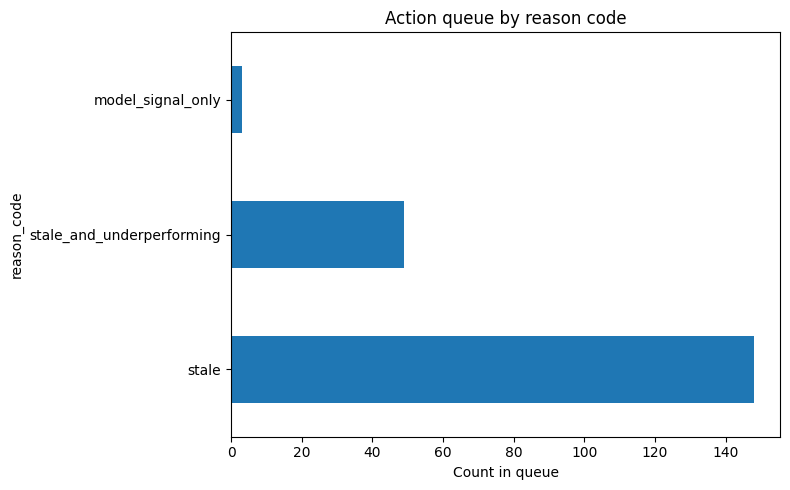

In [ ]:


# Reason code distribution — one figure, reused in the paper
fig, ax = plt.subplots(figsize=(8, 5))
queue_df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Count in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

In [ ]:
print("ML-10 self-check")
print("----------------")

checks = {
    "Queue has 200 rows": len(queue_df) == TOP_N,
    "Reason codes created": queue_df["reason_code"].notna().all(),
    "Recommended actions created": queue_df["recommended_action"].notna().all(),
    "Review set created": len(needs_review) >= 0,
    "Queue CSV exists": os.path.exists("work/outputs/ranked_action_queue.csv"),
    "Metrics JSON exists": os.path.exists("work/outputs/playbook_metrics.json"),
    "Figure exists": os.path.exists("work/figures/reason_code_distribution.png"),
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

print(f"\nQueue rows: {len(queue_df)}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Reason codes used: {queue_df['reason_code'].nunique()}")
print(f"Mandatory review rows: {len(needs_review)}")

ML-10 self-check
----------------
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Review set created
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Queue rows: 200
Clients: 32
Reason codes used: 3
Mandatory review rows: 120


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# Flag rows needing mandatory review before any action

needs_review = queue_df[
    (queue_df["reason_code"] == "model_signal_only") |
    (queue_df["model_score"] < queue_df["model_score"].quantile(0.6))
].copy()

review_count = len(needs_review)
queue_count = len(queue_df)
review_pct = review_count / queue_count * 100

print(
    f"{review_count} of {queue_count} queue rows "
    f"flagged for mandatory review ({review_pct:.1f}%)"
)

120 of 200 queue rows flagged for mandatory review (60.0%)


### Human review and guardrails


Of the top 200 queue recommendations, **120 pages (60%) require mandatory human review** before taking action.

Review triggers are split into two categories:
* **`model_signal_only` cases:** Pages flagged by the model without clear rule-based triggers.
* **Marginal-confidence scores:** Pages sitting near the lower score threshold of the top-200 queue.

> **Key takeaway:** These guardrails ensure the model operates strictly as a decision-support ranking tool. Automated script execution across these flagged rows is prohibited—final actions require explicit editorial sign-off.


#### Cost/value logic & prioritization strategy

Because editorial review time is finite, the queue prioritizes low-cost, high-impact interventions before escalating to expensive content rewrites.

* **Protect high-exposure traffic (`high_traffic_stale`):** Prioritize these first. Since these pages already drive significant volume ($\ge$5,000 impressions), preventing traffic decay yields the highest relative ROI.
* **Default to low-cost fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta description rewrites. Metadata tweaks take minutes; full page rewrites take hours.
* **Filter out technical false positives (`unranked`):** Audit Search Console for indexing issues before assigning content work. Rewriting copy won't fix a page that Google isn't indexing.
* **Require human triage for edge cases (`model_signal_only`):** Without explicit rule flags, human judgment is required to determine if a full audit is warranted.
* **Reserve full updates for high-confidence candidates:** Full content rewrites should only happen after lighter interventions fail or human review confirms severe content decay.

> **Note:** The model ranks relative decline risk, not direct dollar impact. This cost/value framework functions as an operational effort filter, not a financial revenue forecast.



#### Non-negotiable no-go list

- **No automated publishing or updates:** Do not automatically generate, rewrite, or publish content changes. Every recommendation should be reviewed and approved by an editor.
- **No automatic de-indexing or deprioritization:** A high decline score alone is not enough to remove or deprioritize a page. Business context and technical SEO should be reviewed first.
- **No performance monitoring for staff:** The model predicts page-level decline, not the quality or performance of writers or editorial teams. It should not be used for staff evaluation.
- **No bulk actions without spot-checking:** Do not apply changes across the entire queue. Review a representative sample first to confirm that the recommendations are appropriate before taking larger-scale action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
monitoring_reference = {
    "model_precision_at_50_grouped": {"mean": 0.872, "std": 0.069},
    "baseline_precision_at_50_grouped": {"mean": 0.788, "std": 0.124},
    "n_clients_at_training": int(df["client_id"].nunique()),
}

### Monitoring and retraining triggers

Re-evaluate or retrain the model when any of the following conditions are met:

* **P@50 drops below baseline:** Precision@50 on new incoming data falls below the **0.788** rule-based benchmark.
* **Fold variability increases:** Precision@50 becomes substantially more variable across client groups than the current Random Forest result of **0.872 ± 0.069**.
* **New client onboarded:** Evaluate model performance on the new client's data first. Retrain if metrics degrade or data distributions diverge significantly from the 32-client training set.
* **Quarterly cadence reached:** Re-evaluate and refresh quarterly because the current model was developed from a single snapshot and may become less representative as the data changes.

> **Validation Gate:** A triggered retrain does not automatically deploy. Any retrained candidate must pass the same grouped cross-validation suite before replacing the current model used for queue generation.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — gitignored by design (work/**/*.csv), notebook regenerates it
export_cols = ["content_id", "client_id", "reason_code", "recommended_action",
               "model_score", "freshness_tier", "avg_position", "ctr", "impressions_90d"]
queue_df[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

# Metrics JSON — this one DOES get committed (not a CSV, not gitignored)
metrics = {
    **monitoring_reference,
    "queue_size": TOP_N,
    "reason_code_counts": queue_df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue + metrics")

Exported queue + metrics


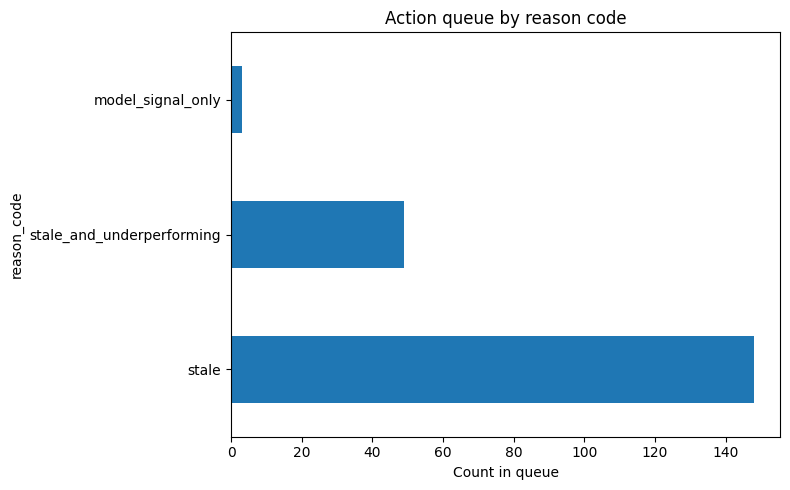

In [ ]:


# Reason code distribution — one figure, reused in the paper
fig, ax = plt.subplots(figsize=(8, 5))
queue_df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Count in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

In [ ]:
print("ML-10 self-check")
print("----------------")

checks = {
    "Queue has 200 rows": len(queue_df) == TOP_N,
    "Reason codes created": queue_df["reason_code"].notna().all(),
    "Recommended actions created": queue_df["recommended_action"].notna().all(),
    "Review set created": len(needs_review) >= 0,
    "Queue CSV exists": os.path.exists("work/outputs/ranked_action_queue.csv"),
    "Metrics JSON exists": os.path.exists("work/outputs/playbook_metrics.json"),
    "Figure exists": os.path.exists("work/figures/reason_code_distribution.png"),
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

print(f"\nQueue rows: {len(queue_df)}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Reason codes used: {queue_df['reason_code'].nunique()}")
print(f"Mandatory review rows: {len(needs_review)}")

ML-10 self-check
----------------
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Review set created
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Queue rows: 200
Clients: 32
Reason codes used: 3
Mandatory review rows: 120


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# Flag rows needing mandatory review before any action

needs_review = queue_df[
    (queue_df["reason_code"] == "model_signal_only") |
    (queue_df["model_score"] < queue_df["model_score"].quantile(0.6))
].copy()

review_count = len(needs_review)
queue_count = len(queue_df)
review_pct = review_count / queue_count * 100

print(
    f"{review_count} of {queue_count} queue rows "
    f"flagged for mandatory review ({review_pct:.1f}%)"
)

120 of 200 queue rows flagged for mandatory review (60.0%)


### Human review and guardrails


Of the top 200 queue recommendations, **120 pages (60%) require mandatory human review** before taking action.

Review triggers are split into two categories:
* **`model_signal_only` cases:** Pages flagged by the model without clear rule-based triggers.
* **Marginal-confidence scores:** Pages sitting near the lower score threshold of the top-200 queue.

> **Key takeaway:** These guardrails ensure the model operates strictly as a decision-support ranking tool. Automated script execution across these flagged rows is prohibited—final actions require explicit editorial sign-off.


#### Cost/value logic & prioritization strategy

Because editorial review time is finite, the queue prioritizes low-cost, high-impact interventions before escalating to expensive content rewrites.

* **Protect high-exposure traffic (`high_traffic_stale`):** Prioritize these first. Since these pages already drive significant volume ($\ge$5,000 impressions), preventing traffic decay yields the highest relative ROI.
* **Default to low-cost fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta description rewrites. Metadata tweaks take minutes; full page rewrites take hours.
* **Filter out technical false positives (`unranked`):** Audit Search Console for indexing issues before assigning content work. Rewriting copy won't fix a page that Google isn't indexing.
* **Require human triage for edge cases (`model_signal_only`):** Without explicit rule flags, human judgment is required to determine if a full audit is warranted.
* **Reserve full updates for high-confidence candidates:** Full content rewrites should only happen after lighter interventions fail or human review confirms severe content decay.

> **Note:** The model ranks relative decline risk, not direct dollar impact. This cost/value framework functions as an operational effort filter, not a financial revenue forecast.



#### Non-negotiable no-go list

- **No automated publishing or updates:** Do not automatically generate, rewrite, or publish content changes. Every recommendation should be reviewed and approved by an editor.
- **No automatic de-indexing or deprioritization:** A high decline score alone is not enough to remove or deprioritize a page. Business context and technical SEO should be reviewed first.
- **No performance monitoring for staff:** The model predicts page-level decline, not the quality or performance of writers or editorial teams. It should not be used for staff evaluation.
- **No bulk actions without spot-checking:** Do not apply changes across the entire queue. Review a representative sample first to confirm that the recommendations are appropriate before taking larger-scale action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
monitoring_reference = {
    "model_precision_at_50_grouped": {"mean": 0.872, "std": 0.069},
    "baseline_precision_at_50_grouped": {"mean": 0.788, "std": 0.124},
    "n_clients_at_training": int(df["client_id"].nunique()),
}

### Monitoring and retraining triggers

Re-evaluate or retrain the model when any of the following conditions are met:

* **P@50 drops below baseline:** Precision@50 on new incoming data falls below the **0.788** rule-based benchmark.
* **Fold variability increases:** Precision@50 becomes substantially more variable across client groups than the current Random Forest result of **0.872 ± 0.069**.
* **New client onboarded:** Evaluate model performance on the new client's data first. Retrain if metrics degrade or data distributions diverge significantly from the 32-client training set.
* **Quarterly cadence reached:** Re-evaluate and refresh quarterly because the current model was developed from a single snapshot and may become less representative as the data changes.

> **Validation Gate:** A triggered retrain does not automatically deploy. Any retrained candidate must pass the same grouped cross-validation suite before replacing the current model used for queue generation.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — gitignored by design (work/**/*.csv), notebook regenerates it
export_cols = ["content_id", "client_id", "reason_code", "recommended_action",
               "model_score", "freshness_tier", "avg_position", "ctr", "impressions_90d"]
queue_df[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

# Metrics JSON — this one DOES get committed (not a CSV, not gitignored)
metrics = {
    **monitoring_reference,
    "queue_size": TOP_N,
    "reason_code_counts": queue_df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue + metrics")

Exported queue + metrics


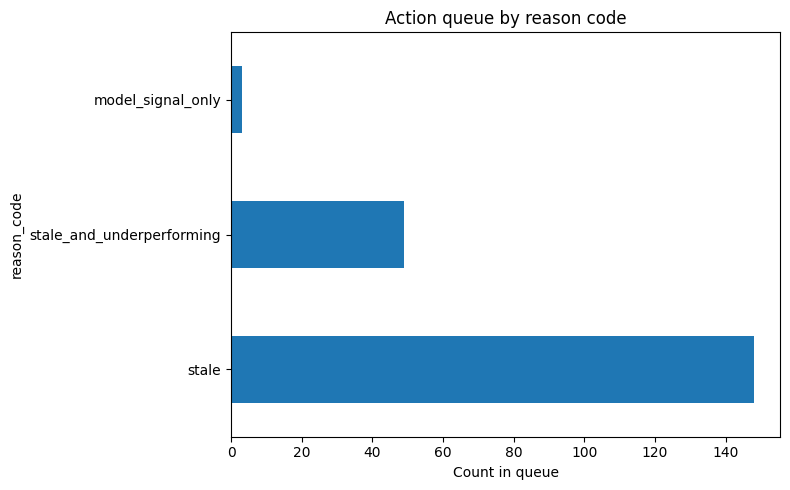

In [ ]:


# Reason code distribution — one figure, reused in the paper
fig, ax = plt.subplots(figsize=(8, 5))
queue_df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Count in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

In [ ]:
print("ML-10 self-check")
print("----------------")

checks = {
    "Queue has 200 rows": len(queue_df) == TOP_N,
    "Reason codes created": queue_df["reason_code"].notna().all(),
    "Recommended actions created": queue_df["recommended_action"].notna().all(),
    "Review set created": len(needs_review) >= 0,
    "Queue CSV exists": os.path.exists("work/outputs/ranked_action_queue.csv"),
    "Metrics JSON exists": os.path.exists("work/outputs/playbook_metrics.json"),
    "Figure exists": os.path.exists("work/figures/reason_code_distribution.png"),
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

print(f"\nQueue rows: {len(queue_df)}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Reason codes used: {queue_df['reason_code'].nunique()}")
print(f"Mandatory review rows: {len(needs_review)}")

ML-10 self-check
----------------
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Review set created
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Queue rows: 200
Clients: 32
Reason codes used: 3
Mandatory review rows: 120


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [36]:
# Flag rows needing mandatory review before any action

needs_review = queue_df[
    (queue_df["reason_code"] == "model_signal_only") |
    (queue_df["model_score"] < queue_df["model_score"].quantile(0.6))
].copy()

review_count = len(needs_review)
queue_count = len(queue_df)
review_pct = review_count / queue_count * 100

print(
    f"{review_count} of {queue_count} queue rows "
    f"flagged for mandatory review ({review_pct:.1f}%)"
)

120 of 200 queue rows flagged for mandatory review (60.0%)


### Human review and guardrails


Of the top 200 queue recommendations, **120 pages (60%) require mandatory human review** before taking action.

Review triggers are split into two categories:
* **`model_signal_only` cases:** Pages flagged by the model without clear rule-based triggers.
* **Marginal-confidence scores:** Pages sitting near the lower score threshold of the top-200 queue.

> **Key takeaway:** These guardrails ensure the model operates strictly as a decision-support ranking tool. Automated script execution across these flagged rows is prohibited—final actions require explicit editorial sign-off.


#### Cost/value logic & prioritization strategy

Because editorial review time is finite, the queue prioritizes low-cost, high-impact interventions before escalating to expensive content rewrites.

* **Protect high-exposure traffic (`high_traffic_stale`):** Prioritize these first. Since these pages already drive significant volume ($\ge$5,000 impressions), preventing traffic decay yields the highest relative ROI.
* **Default to low-cost fixes (`stale_and_underperforming`, `low_ctr`):** Start with title and meta description rewrites. Metadata tweaks take minutes; full page rewrites take hours.
* **Filter out technical false positives (`unranked`):** Audit Search Console for indexing issues before assigning content work. Rewriting copy won't fix a page that Google isn't indexing.
* **Require human triage for edge cases (`model_signal_only`):** Without explicit rule flags, human judgment is required to determine if a full audit is warranted.
* **Reserve full updates for high-confidence candidates:** Full content rewrites should only happen after lighter interventions fail or human review confirms severe content decay.

> **Note:** The model ranks relative decline risk, not direct dollar impact. This cost/value framework functions as an operational effort filter, not a financial revenue forecast.



#### Non-negotiable no-go list

- **No automated publishing or updates:** Do not automatically generate, rewrite, or publish content changes. Every recommendation should be reviewed and approved by an editor.
- **No automatic de-indexing or deprioritization:** A high decline score alone is not enough to remove or deprioritize a page. Business context and technical SEO should be reviewed first.
- **No performance monitoring for staff:** The model predicts page-level decline, not the quality or performance of writers or editorial teams. It should not be used for staff evaluation.
- **No bulk actions without spot-checking:** Do not apply changes across the entire queue. Review a representative sample first to confirm that the recommendations are appropriate before taking larger-scale action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [30]:
monitoring_reference = {
    "model_precision_at_50_grouped": {"mean": 0.872, "std": 0.069},
    "baseline_precision_at_50_grouped": {"mean": 0.788, "std": 0.124},
    "n_clients_at_training": int(df["client_id"].nunique()),
}

### Monitoring and retraining triggers

Re-evaluate or retrain the model when any of the following conditions are met:

* **P@50 drops below baseline:** Precision@50 on new incoming data falls below the **0.788** rule-based benchmark.
* **Fold variability increases:** Precision@50 becomes substantially more variable across client groups than the current Random Forest result of **0.872 ± 0.069**.
* **New client onboarded:** Evaluate model performance on the new client's data first. Retrain if metrics degrade or data distributions diverge significantly from the 32-client training set.
* **Quarterly cadence reached:** Re-evaluate and refresh quarterly because the current model was developed from a single snapshot and may become less representative as the data changes.

> **Validation Gate:** A triggered retrain does not automatically deploy. Any retrained candidate must pass the same grouped cross-validation suite before replacing the current model used for queue generation.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [40]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — gitignored by design (work/**/*.csv), notebook regenerates it
export_cols = ["content_id", "client_id", "reason_code", "recommended_action",
               "model_score", "freshness_tier", "avg_position", "ctr", "impressions_90d"]
queue_df[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

# Metrics JSON — this one DOES get committed (not a CSV, not gitignored)
metrics = {
    **monitoring_reference,
    "queue_size": TOP_N,
    "reason_code_counts": queue_df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue + metrics")

Exported queue + metrics


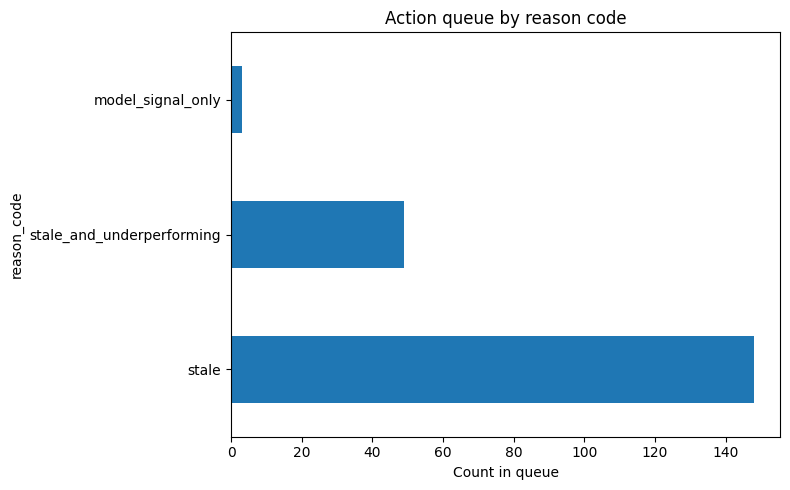

In [32]:


# Reason code distribution — one figure, reused in the paper
fig, ax = plt.subplots(figsize=(8, 5))
queue_df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Count in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

In [41]:
print("ML-10 self-check")
print("----------------")

checks = {
    "Queue has 200 rows": len(queue_df) == TOP_N,
    "Reason codes created": queue_df["reason_code"].notna().all(),
    "Recommended actions created": queue_df["recommended_action"].notna().all(),
    "Review set created": len(needs_review) >= 0,
    "Queue CSV exists": os.path.exists("work/outputs/ranked_action_queue.csv"),
    "Metrics JSON exists": os.path.exists("work/outputs/playbook_metrics.json"),
    "Figure exists": os.path.exists("work/figures/reason_code_distribution.png"),
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

print(f"\nQueue rows: {len(queue_df)}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Reason codes used: {queue_df['reason_code'].nunique()}")
print(f"Mandatory review rows: {len(needs_review)}")

ML-10 self-check
----------------
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Review set created
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Queue rows: 200
Clients: 32
Reason codes used: 3
Mandatory review rows: 120


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.